---

<center>

# **Proyecto Final: Ecuaciones Parabolicas en 2D con Elemntos Finitos**

**Realizado por:**

Samuel Huertas Rojas

</center>

---

=== Simulación de Propagación de Calor ===
Material: Acero
Dimensiones: 0.2m × 0.2m
Difusividad térmica α = 1.31e-05 m²/s
Mallado: 25×25 nodos (576 elementos)
Tiempo de simulación: 30.0 s

Visualizando funciones techo...


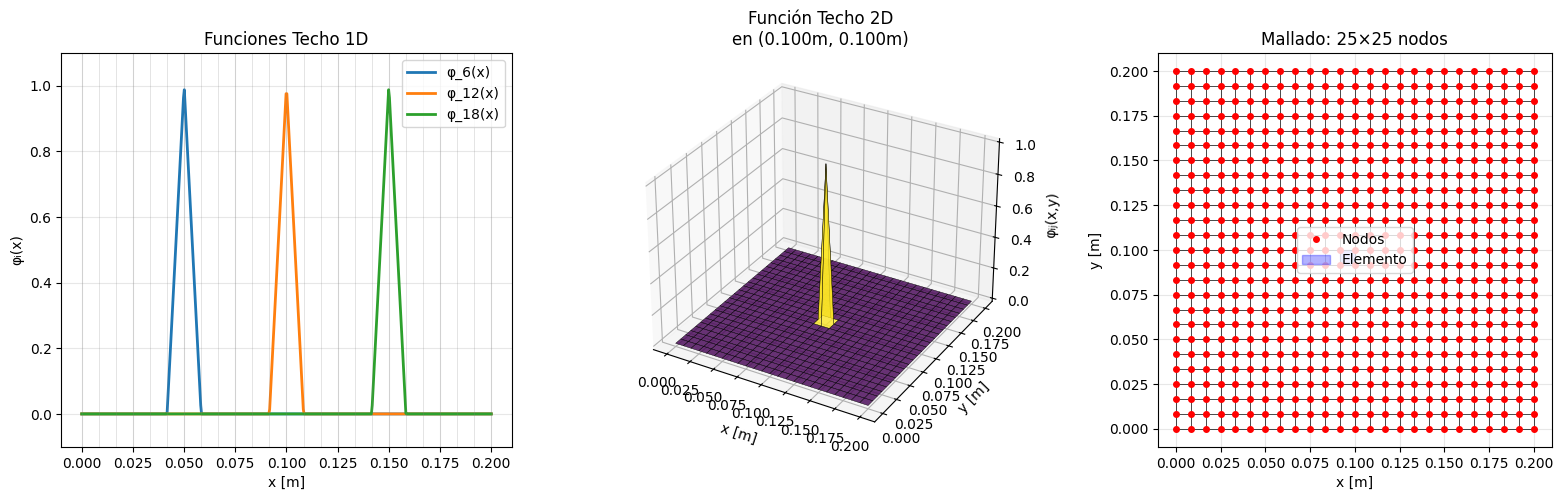


Ensamblando matrices con funciones techo...
Resolviendo 200 pasos temporales (θ=0.5)...
  t = 3.015s | T_min = -42417526.7°C, T_max = 5290294778.1°C
  t = 6.030s | T_min = -5551162.0°C, T_max = 5332231521.6°C
  t = 9.045s | T_min = -2011658.5°C, T_max = 5345979512.2°C
  t = 12.060s | T_min = -361531.3°C, T_max = 5352795060.1°C
  t = 15.075s | T_min = -170896.0°C, T_max = 5356864728.6°C
  t = 18.090s | T_min = -61578.8°C, T_max = 5359569476.2°C
  t = 21.106s | T_min = -30098.2°C, T_max = 5361497294.2°C
  t = 24.121s | T_min = 16893.2°C, T_max = 5362940874.4°C
  t = 27.136s | T_min = 342911.1°C, T_max = 5364062299.1°C
¡Simulación completada!
Animación guardada como heat_propagation.gif


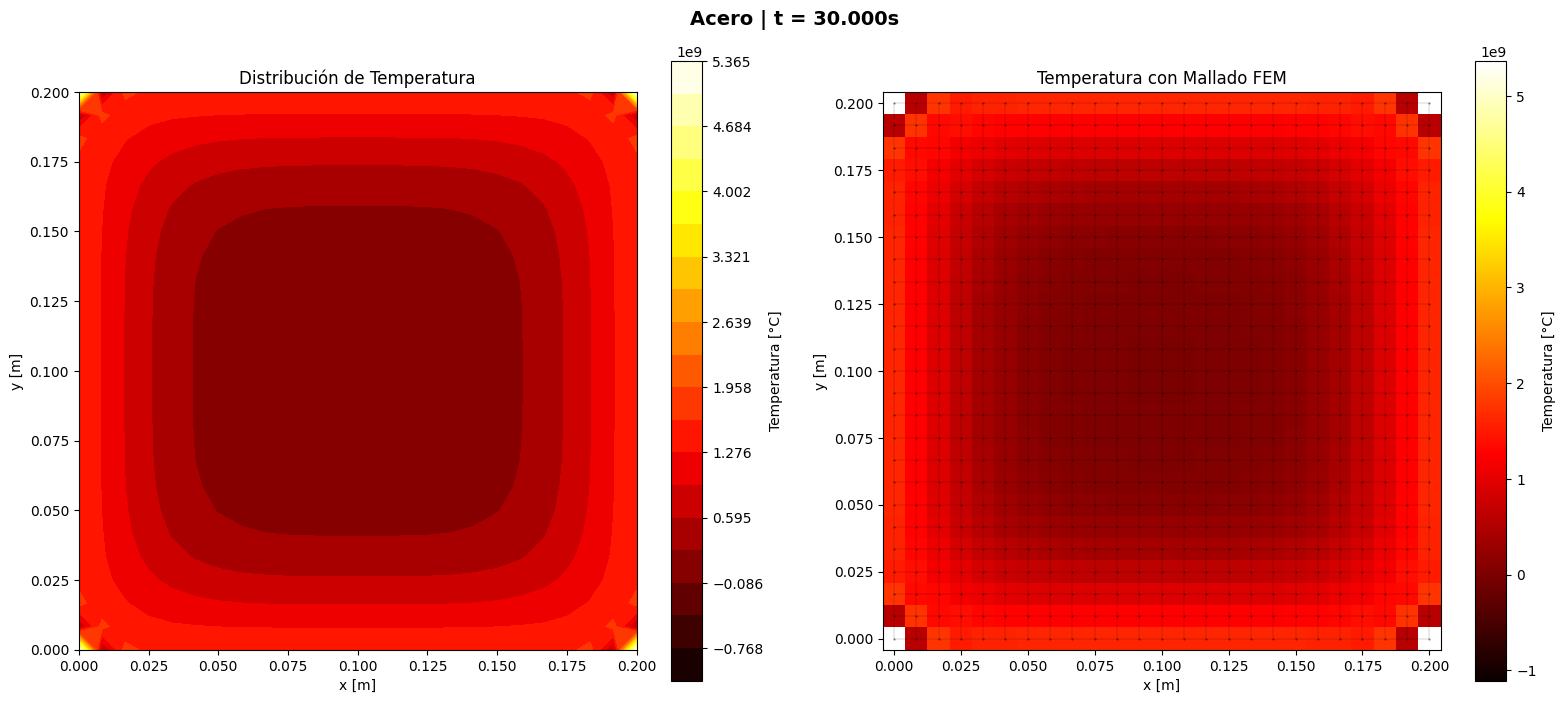

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

class HeatEquationFEM2D:
    """
    Resuelve la ecuación de conducción de calor en 2D usando funciones techo (hat functions).
    
    Ecuación del calor: ρc ∂T/∂t = k(∂²T/∂x² + ∂²T/∂y²) + Q(x,y,t)
    
    Donde:
    - T: temperatura [K o °C]
    - ρ: densidad del material [kg/m³]
    - c: calor específico [J/(kg·K)]
    - k: conductividad térmica [W/(m·K)]
    - Q: fuente de calor [W/m³]
    
    Funciones techo φᵢⱼ(x,y):
    - φᵢⱼ(xᵢ, yⱼ) = 1 (en su nodo)
    - φᵢⱼ(otros nodos) = 0
    - Lineales por partes: φᵢⱼ(x,y) = φᵢ(x) · φⱼ(y)
    """
    
    def __init__(self, Lx, Ly, T_final, nx, ny, nt, material='acero'):
        """
        Parámetros:
        - Lx, Ly: dimensiones del material [m]
        - T_final: tiempo final de simulación [s]
        - nx, ny: número de nodos en x e y
        - nt: número de pasos temporales
        - material: tipo de material ('acero', 'aluminio', 'cobre', 'concreto')
        """
        self.Lx = Lx
        self.Ly = Ly
        self.T_final = T_final
        self.nx = nx
        self.ny = ny
        self.nt = nt
        
        # Propiedades térmicas del material
        self.set_material(material)
        
        # Difusividad térmica: α = k/(ρc) [m²/s]
        self.alpha = self.k / (self.rho * self.c)
        
        # Mallas espaciales y temporales
        self.x = np.linspace(0, Lx, nx)
        self.y = np.linspace(0, Ly, ny)
        self.t = np.linspace(0, T_final, nt)
        self.dt = T_final / (nt - 1)
        self.hx = Lx / (nx - 1)
        self.hy = Ly / (ny - 1)
        
        # Malla 2D
        self.X, self.Y = np.meshgrid(self.x, self.y)
        
        # Número total de nodos
        self.N = nx * ny
        
        # Historia de temperaturas
        self.T_history = []
        
        print(f"=== Simulación de Propagación de Calor ===")
        print(f"Material: {self.material_name}")
        print(f"Dimensiones: {Lx}m × {Ly}m")
        print(f"Difusividad térmica α = {self.alpha:.2e} m²/s")
        print(f"Mallado: {nx}×{ny} nodos ({(nx-1)*(ny-1)} elementos)")
        print(f"Tiempo de simulación: {T_final} s")
        
    def set_material(self, material):
        """Define propiedades térmicas del material"""
        materials = {
            'acero': {
                'name': 'Acero',
                'rho': 7850,    # kg/m³
                'c': 490,       # J/(kg·K)
                'k': 50.2       # W/(m·K)
            },
            'aluminio': {
                'name': 'Aluminio',
                'rho': 2700,
                'c': 897,
                'k': 237
            },
            'cobre': {
                'name': 'Cobre',
                'rho': 8960,
                'c': 385,
                'k': 401
            },
            'concreto': {
                'name': 'Concreto',
                'rho': 2300,
                'c': 880,
                'k': 1.4
            }
        }
        
        mat = materials.get(material, materials['acero'])
        self.material_name = mat['name']
        self.rho = mat['rho']
        self.c = mat['c']
        self.k = mat['k']
    
    def node_index(self, i, j):
        """Convierte índices (i,j) a índice global"""
        return i + j * self.nx
    
    def is_boundary(self, i, j):
        """Verifica si un nodo está en la frontera"""
        return i == 0 or i == self.nx-1 or j == 0 or j == self.ny-1
    
    def hat_function_1d(self, x, xi, h):
        """
        Función techo 1D centrada en xi con soporte [xi-h, xi+h]
        
        φᵢ(x) = {
            (x - xᵢ₋₁)/h   si xᵢ₋₁ ≤ x ≤ xᵢ
            (xᵢ₊₁ - x)/h   si xᵢ ≤ x ≤ xᵢ₊₁
            0              en otro caso
        }
        """
        if xi - h <= x <= xi:
            return (x - (xi - h)) / h
        elif xi < x <= xi + h:
            return (xi + h - x) / h
        else:
            return 0.0
    
    def initial_temperature(self, x, y):
        """
        Temperatura inicial T(x,y,0) [°C]
        Ejemplo: placa a temperatura ambiente con fuente de calor puntual
        """
        T_ambient = 20.0  # °C
        
        # Fuente de calor en el centro (soldadura, calentador, etc.)
        x0, y0 = self.Lx/2, self.Ly/2
        radius = min(self.Lx, self.Ly) / 8
        dist = np.sqrt((x - x0)**2 + (y - y0)**2)
        
        if dist < radius:
            T_hot = 200.0  # °C
            return T_ambient + (T_hot - T_ambient) * (1 - dist/radius)
        else:
            return T_ambient
    
    def boundary_temperature(self, x, y, t):
        """
        Temperatura en la frontera T(frontera, t) [°C]
        Condición de Dirichlet: bordes a temperatura ambiente
        """
        return 20.0  # °C (temperatura ambiente)
    
    def heat_source(self, x, y, t):
        """
        Fuente de calor Q(x,y,t) [W/m³]
        Puede simular resistencias eléctricas, reacciones químicas, etc.
        """
        # Sin fuente de calor adicional (solo conducción)
        return 0.0
        
        # Ejemplo: fuente pulsante en el centro
        # x0, y0 = self.Lx/2, self.Ly/2
        # radius = 0.05
        # dist = np.sqrt((x - x0)**2 + (y - y0)**2)
        # if dist < radius and t < self.T_final/2:
        #     return 1e6  # W/m³
        # return 0.0
    
    def assemble_matrices(self):
        """
        Ensambla matrices usando funciones techo bilineales.
        
        Base de funciones: {φᵢⱼ(x,y) = φᵢ(x)φⱼ(y)}
        
        Matriz de masa: Mᵢⱼ = ρc ∫∫ φᵢφⱼ dxdy
        Matriz de rigidez: Kᵢⱼ = k ∫∫ ∇φᵢ·∇φⱼ dxdy
        """
        M = lil_matrix((self.N, self.N))
        K = lil_matrix((self.N, self.N))
        
        hx, hy = self.hx, self.hy
        
        # Matriz de masa local (integración exacta de productos de funciones techo)
        # Orden: nodo (i,j), (i+1,j), (i,j+1), (i+1,j+1)
        m_local = (self.rho * self.c * hx * hy / 36) * np.array([
            [4, 2, 2, 1],
            [2, 4, 1, 2],
            [2, 1, 4, 2],
            [1, 2, 2, 4]
        ])
        
        # Matriz de rigidez local (integración de gradientes)
        # Componente x: ∫∫ (∂φᵢ/∂x)(∂φⱼ/∂x) dxdy
        k_local_x = (self.k * hy / (6 * hx)) * np.array([
            [ 2, -2,  1, -1],
            [-2,  2, -1,  1],
            [ 1, -1,  2, -2],
            [-1,  1, -2,  2]
        ])
        
        # Componente y: ∫∫ (∂φᵢ/∂y)(∂φⱼ/∂y) dxdy
        k_local_y = (self.k * hx / (6 * hy)) * np.array([
            [ 2,  1, -2, -1],
            [ 1,  2, -1, -2],
            [-2, -1,  2,  1],
            [-1, -2,  1,  2]
        ])
        
        k_local = k_local_x + k_local_y
        
        # Ensamblaje elemento por elemento
        for j in range(self.ny - 1):
            for i in range(self.nx - 1):
                # Nodos del elemento (función techo con soporte en 4 nodos)
                nodes = [
                    self.node_index(i, j),      # esquina inferior izquierda
                    self.node_index(i+1, j),    # esquina inferior derecha
                    self.node_index(i, j+1),    # esquina superior izquierda
                    self.node_index(i+1, j+1)   # esquina superior derecha
                ]
                
                # Contribución de este elemento a las matrices globales
                for a in range(4):
                    for b in range(4):
                        M[nodes[a], nodes[b]] += m_local[a, b]
                        K[nodes[a], nodes[b]] += k_local[a, b]
        
        return csr_matrix(M), csr_matrix(K)
    
    def apply_boundary_conditions(self, M, K, F, T, t):
        """Aplica condiciones de frontera de temperatura"""
        for j in range(self.ny):
            for i in range(self.nx):
                if self.is_boundary(i, j):
                    idx = self.node_index(i, j)
                    x, y = self.x[i], self.y[j]
                    
                    # Método de penalización
                    penalty = 1e10
                    M[idx, idx] = penalty
                    K[idx, idx] = 0
                    F[idx] = penalty * self.boundary_temperature(x, y, t)
                    
                    # Limpiar fila
                    for k in range(self.N):
                        if k != idx:
                            K[idx, k] = 0
        
        return M, K, F
    
    def solve(self, theta=0.5):
        """
        Resuelve la ecuación del calor usando esquema θ-method
        
        θ = 0.0: Euler explícito (requiere Δt pequeño)
        θ = 0.5: Crank-Nicolson (óptimo, incondicionalmente estable)
        θ = 1.0: Euler implícito (muy estable pero menos preciso)
        """
        print(f"\nEnsamblando matrices con funciones techo...")
        M, K = self.assemble_matrices()
        
        # Temperatura inicial
        T = np.zeros(self.N)
        for j in range(self.ny):
            for i in range(self.nx):
                idx = self.node_index(i, j)
                T[idx] = self.initial_temperature(self.x[i], self.y[j])
        
        self.T_history.append(T.copy().reshape(self.ny, self.nx))
        
        # Sistema discretizado
        A_left = M + theta * self.dt * K
        A_right = M - (1 - theta) * self.dt * K
        
        print(f"Resolviendo {self.nt} pasos temporales (θ={theta})...")
        for n in range(1, self.nt):
            t_current = self.t[n]
            
            # Vector de fuentes de calor
            Q = np.zeros(self.N)
            for j in range(self.ny):
                for i in range(self.nx):
                    idx = self.node_index(i, j)
                    Q[idx] = self.heat_source(self.x[i], self.y[j], t_current)
            
            # Lado derecho del sistema
            b = A_right @ T + self.dt * Q
            
            # Aplicar condiciones de frontera
            A_left_copy = A_left.copy()
            _, _, b = self.apply_boundary_conditions(
                lil_matrix(A_left_copy.shape),
                lil_matrix(A_left_copy),
                b, T, t_current
            )
            
            # Resolver sistema lineal
            T = spsolve(csr_matrix(A_left_copy), b)
            
            # Guardar temperatura
            self.T_history.append(T.copy().reshape(self.ny, self.nx))
            
            if (n % max(1, self.nt // 10)) == 0:
                T_min, T_max = T.min(), T.max()
                print(f"  t = {t_current:.3f}s | T_min = {T_min:.1f}°C, T_max = {T_max:.1f}°C")
        
        print("¡Simulación completada!")
    
    def plot_hat_functions(self):
        """Visualiza las funciones techo utilizadas"""
        fig = plt.figure(figsize=(16, 5))
        
        # Panel 1: Función techo 1D
        ax1 = fig.add_subplot(131)
        x_fine = np.linspace(0, self.Lx, 500)
        
        # Mostrar varias funciones techo
        for i in [self.nx//4, self.nx//2, 3*self.nx//4]:
            if 0 <= i < self.nx:
                phi = np.array([self.hat_function_1d(x, self.x[i], self.hx) 
                               for x in x_fine])
                ax1.plot(x_fine, phi, linewidth=2, label=f'φ_{i}(x)')
        
        for xi in self.x:
            ax1.axvline(x=xi, color='gray', linewidth=0.5, alpha=0.3)
        
        ax1.set_xlabel('x [m]')
        ax1.set_ylabel('φᵢ(x)')
        ax1.set_title('Funciones Techo 1D')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(-0.1, 1.1)
        
        # Panel 2: Función techo 2D
        ax2 = fig.add_subplot(132, projection='3d')
        
        mid_i, mid_j = self.nx // 2, self.ny // 2
        phi_2d = np.zeros_like(self.X)
        
        for j in range(self.ny):
            for i in range(self.nx):
                phi_x = self.hat_function_1d(self.x[i], self.x[mid_i], self.hx)
                phi_y = self.hat_function_1d(self.y[j], self.y[mid_j], self.hy)
                phi_2d[j, i] = phi_x * phi_y
        
        surf = ax2.plot_surface(self.X, self.Y, phi_2d, cmap='viridis',
                               edgecolor='k', linewidth=0.3, alpha=0.8)
        ax2.set_xlabel('x [m]')
        ax2.set_ylabel('y [m]')
        ax2.set_zlabel('φᵢⱼ(x,y)')
        ax2.set_title(f'Función Techo 2D\nen ({self.x[mid_i]:.3f}m, {self.y[mid_j]:.3f}m)')
        
        # Panel 3: Mallado
        ax3 = fig.add_subplot(133)
        
        for i in range(self.nx):
            ax3.plot([self.x[i], self.x[i]], [self.y[0], self.y[-1]],
                    'k-', linewidth=0.5)
        for j in range(self.ny):
            ax3.plot([self.x[0], self.x[-1]], [self.y[j], self.y[j]],
                    'k-', linewidth=0.5)
        
        ax3.plot(self.X.flatten(), self.Y.flatten(), 'ro',
                markersize=4, label='Nodos')
        
        # Resaltar elemento central
        ei, ej = mid_i-1, mid_j-1
        if ei >= 0 and ej >= 0:
            x_elem = [self.x[ei], self.x[ei+1], self.x[ei+1], self.x[ei], self.x[ei]]
            y_elem = [self.y[ej], self.y[ej], self.y[ej+1], self.y[ej+1], self.y[ej]]
            ax3.fill(x_elem, y_elem, alpha=0.3, color='blue', label='Elemento')
        
        ax3.set_xlabel('x [m]')
        ax3.set_ylabel('y [m]')
        ax3.set_title(f'Mallado: {self.nx}×{self.ny} nodos')
        ax3.set_aspect('equal')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def animate(self, interval=50, save_as=None):
        """Anima la propagación del calor"""
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        T_min = min(T.min() for T in self.T_history)
        T_max = max(T.max() for T in self.T_history)
        
        # Panel izquierdo: temperatura con contornos
        ax1 = axes[0]
        levels = np.linspace(T_min, T_max, 20)
        im1 = ax1.contourf(self.X, self.Y, self.T_history[0],
                          levels=levels, cmap='hot', vmin=T_min, vmax=T_max)
        cbar1 = plt.colorbar(im1, ax=ax1, label='Temperatura [°C]')
        ax1.set_xlabel('x [m]')
        ax1.set_ylabel('y [m]')
        ax1.set_aspect('equal')
        ax1.set_title('Distribución de Temperatura')
        
        # Panel derecho: temperatura con mallado
        ax2 = axes[1]
        im2 = ax2.pcolormesh(self.X, self.Y, self.T_history[0],
                            cmap='hot', vmin=T_min, vmax=T_max, shading='auto')
        
        # Dibujar mallado
        for i in range(self.nx):
            ax2.plot([self.x[i], self.x[i]], [self.y[0], self.y[-1]],
                    'k-', linewidth=0.3, alpha=0.4)
        for j in range(self.ny):
            ax2.plot([self.x[0], self.x[-1]], [self.y[j], self.y[j]],
                    'k-', linewidth=0.3, alpha=0.4)
        ax2.plot(self.X.flatten(), self.Y.flatten(), 'k.',
                markersize=1, alpha=0.5)
        
        cbar2 = plt.colorbar(im2, ax=ax2, label='Temperatura [°C]')
        ax2.set_xlabel('x [m]')
        ax2.set_ylabel('y [m]')
        ax2.set_aspect('equal')
        ax2.set_title('Temperatura con Mallado FEM')
        
        fig.suptitle(f'{self.material_name} | t = {self.t[0]:.3f}s',
                    fontsize=14, fontweight='bold')
        
        def update(frame):
            ax1.clear()
            ax2.clear()
            
            # Actualizar contornos
            im1 = ax1.contourf(self.X, self.Y, self.T_history[frame],
                              levels=levels, cmap='hot', vmin=T_min, vmax=T_max)
            ax1.set_xlabel('x [m]')
            ax1.set_ylabel('y [m]')
            ax1.set_aspect('equal')
            ax1.set_title('Distribución de Temperatura')
            
            # Actualizar con mallado
            im2 = ax2.pcolormesh(self.X, self.Y, self.T_history[frame],
                                cmap='hot', vmin=T_min, vmax=T_max, shading='auto')
            
            for i in range(self.nx):
                ax2.plot([self.x[i], self.x[i]], [self.y[0], self.y[-1]],
                        'k-', linewidth=0.3, alpha=0.4)
            for j in range(self.ny):
                ax2.plot([self.x[0], self.x[-1]], [self.y[j], self.y[j]],
                        'k-', linewidth=0.3, alpha=0.4)
            ax2.plot(self.X.flatten(), self.Y.flatten(), 'k.',
                    markersize=1, alpha=0.5)
            
            ax2.set_xlabel('x [m]')
            ax2.set_ylabel('y [m]')
            ax2.set_aspect('equal')
            ax2.set_title('Temperatura con Mallado FEM')
            
            fig.suptitle(f'{self.material_name} | t = {self.t[frame]:.3f}s',
                        fontsize=14, fontweight='bold')
            
            return im1, im2
        
        anim = FuncAnimation(fig, update, frames=len(self.T_history),
                           interval=interval, blit=False)
        
        if save_as:
            anim.save(save_as, writer='pillow', fps=20)
            print(f"Animación guardada como {save_as}")
        
        plt.tight_layout()
        plt.show()


# Ejemplo: Propagación de calor en una placa de acero
if __name__ == "__main__":
    # Parámetros del problema físico
    Lx, Ly = 0.2, 0.2     # Placa de 20cm × 20cm
    T_final = 30.0         # 30 segundos de simulación
    nx, ny = 25, 25        # Resolución espacial
    nt = 200               # Pasos temporales
    material = 'acero'     # Opciones: 'acero', 'aluminio', 'cobre', 'concreto'
    
    # Crear simulador
    solver = HeatEquationFEM2D(Lx, Ly, T_final, nx, ny, nt, material)
    
    # Mostrar funciones techo
    print("\nVisualizando funciones techo...")
    solver.plot_hat_functions()
    
    # Resolver ecuación del calor
    solver.solve(theta=0.5)  # Crank-Nicolson
    
    # Animar propagación del calor
    solver.animate(interval=50, save_as='heat_propagation.gif')